In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

we load the dataset using pandas and explore its basic structure.

In [4]:
# analysis of social media mental health data
# load the social media mental health data:
data_Social = pd.read_csv('/content/social_media_mental_health.csv')

.head() -> shows the first 5 rows to preview the data

In [5]:
data_Social.head()

,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


.shape ->  returns ( rows, coloumns) - tells us how big the dataset is

In [6]:
data_Social.shape

(8000, 15)

.columns ->  lists all column names

In [7]:
data_Social.columns

Index(['User_ID', 'Age', 'Gender', 'User_Archetype', 'Primary_Platform',
       'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type',
       'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours',
       'GAD_7_Score', 'GAD_7_Severity', 'PHQ_9_Score', 'PHQ_9_Severity'],
      dtype='object')

.info() -> shows data types and non-null counts per column

In [8]:
data_Social.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

.describe() -> gives summary statistics for numerical ( mean, std, mix, min, ect.)

In [9]:
data_Social.describe()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,7.354250,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.633108,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,4.000000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,7.000000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,11.000000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,21.000000,23.000000


**What initial odservations can be made about the dataset?**
1. Dataset Size: The dataset contains 8000 rows and 15 columns, representing
   survey responses from individuals about their social media usage and mental health.

2. Column Overview: The dataset includes a mix of:
   - Numerical columns: such as age, time spent on social media, and mental health scores.
   - Categorical columns: such as gender, platform used, and occupation status.

3. No data is missing

4. Data Types: There are three of data object and int64 and float64. Encoding must be used to convert object data into int64 or float64 so that the computer can understand it.

# 2: Data Quality Assessment

In this section, we check the dataset for common data quality issues.

In [10]:
# 1. Missing Values
print("Missing values per column:")
print(data_Social.isnull().sum())

Missing values per column:
User_ID                      0
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Score                  0
GAD_7_Severity               0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64


## 1. Missing Values
How it was found: Using .isnull().sum() to count empty cells in each column.

Evidence: All columns show 0 — no missing values found in this dataset.

In [11]:
# 2. Duplicate Records
print("Number of duplicate rows:", data_Social.duplicated().sum())

Number of duplicate rows: 0


## 2. Duplicate Records
How it was found: Using .duplicated().sum() to detect fully repeated rows.

Evidence:  No duplicate rows found (0 duplicates).

In [12]:
# 3. Inconsistent Labels
cols = ['Gender', 'User_Archetype', 'Primary_Platform',
        'Dominant_Content_Type', 'Activity_Type',
        'GAD_7_Severity', 'PHQ_9_Severity']

for col in cols:
    print(f"\n{col}:")
    print(data_Social[col].value_counts())


Gender:
Gender
Female    4028
Male      3972
Name: count, dtype: int64

User_Archetype:
User_Archetype
Hyper-Connected       2068
Digital Minimalist    2030
Average User          1993
Passive Scroller      1909
Name: count, dtype: int64

Primary_Platform:
Primary_Platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64

Dominant_Content_Type:
Dominant_Content_Type
Lifestyle/Fashion       1387
Entertainment/Comedy    1359
Self-Help/Motivation    1347
Educational/Tech        1303
News/Politics           1303
Gaming                  1301
Name: count, dtype: int64

Activity_Type:
Activity_Type
Active     6091
Passive    1909
Name: count, dtype: int64

GAD_7_Severity:
GAD_7_Severity
Mild        2891
Minimal     2419
Moderate    2145
Severe       545
Name: count, dtype: int64

PHQ_9_Severity:
PHQ_9_Severity
None-Minimal         3966
Mild                 2360
Moderate             1291
Mode

## 3. Inconsistent Labels
How it was found: Using .value_counts() on all categorical columns
to check if the same category appears in different formats (e.g. "Male" vs "male").

Evidence:No inconsistencies found. All labels are consistent —
Gender has only "Female" and "Male", platforms and severity levels
are all written in the same format across all 8000 rows.

In [13]:
# 4. Invalid Values — checking negative or impossible values
print("Age min/max:", data_Social['Age'].min(), "/", data_Social['Age'].max())
print("Screen Time min/max:", data_Social['Daily_Screen_Time_Hours'].min(), "/", data_Social['Daily_Screen_Time_Hours'].max())
print("Sleep Duration min/max:", data_Social['Sleep_Duration_Hours'].min(), "/", data_Social['Sleep_Duration_Hours'].max())
print("GAD_7_Score min/max:", data_Social['GAD_7_Score'].min(), "/", data_Social['GAD_7_Score'].max())
print("PHQ_9_Score min/max:", data_Social['PHQ_9_Score'].min(), "/", data_Social['PHQ_9_Score'].max())

Age min/max: 18 / 22
Screen Time min/max: 0.5 / 11.31
Sleep Duration min/max: 3.0 / 11.6
GAD_7_Score min/max: 0 / 21
PHQ_9_Score min/max: 0 / 23


## 4. Invalid Values
How it was found: Checking min and max of numerical columns for
negative or impossible values.

Evidence: All values are within valid ranges.
- Age: 18 to 22 ✓
- Screen Time: 0.5 to 11.31 hours ✓
- Sleep Duration: 3.0 to 11.6 hours ✓
- GAD_7_Score: 0 to 21 ✓
- PHQ_9_Score: 0 to 23 ✓
No negative or impossible values were detected.

In [14]:
# 5. Mixed or Incorrect Data Types
print(data_Social.dtypes)

User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage               int64
Social_Comparison_Trigger      int64
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object


## 5. Mixed or Incorrect Data Types
How it was found: Using .dtypes to inspect the data type of each column.

Evidence: Late_Night_Usage and Social_Comparison_Trigger are stored
as int64 but only contain 0 and 1, so they should be boolean type.
This will be fixed in the cleaning step.

| Issue | How Detected | Evidence |
|-------|-------------|----------|
| Missing Values | .isnull().sum() | None found — all 15 columns show 0 |
| Duplicate Records | .duplicated().sum() | None found — 0 duplicate rows |
| Inconsistent Labels | .value_counts() | None found — all labels are consistent |
| Invalid Values | Min/Max check | None found — all values within valid range |
| Incorrect Data Types | .dtypes | Late_Night_Usage and Social_Comparison_Trigger should be bool |


## Data cleaning

**1.Handle missing value**

In [15]:

print("Checking for missing values:")
print(data_Social.isnull().sum())


Checking for missing values:
User_ID                      0
Age                          0
Gender                       0
User_Archetype               0
Primary_Platform             0
Daily_Screen_Time_Hours      0
Dominant_Content_Type        0
Activity_Type                0
Late_Night_Usage             0
Social_Comparison_Trigger    0
Sleep_Duration_Hours         0
GAD_7_Score                  0
GAD_7_Severity               0
PHQ_9_Score                  0
PHQ_9_Severity               0
dtype: int64


**Result:** No missing values found

But we will apply the methods as examples:

**Method 1: Mean / Median / Mode**

- Mean: fills with the average — simple but affected by outliers
- Median: fills with the middle value — better when outliers exist
- Mode: fills with the most frequent value — used for categorical columns


In [16]:
# Mean — for numerical column
data_mean = data_Social.copy()
data_mean['GAD_7_Score'].fillna(data_mean['GAD_7_Score'].mean(), inplace=True)
print('Mean applied to GAD_7_Score')

# Median — more robust to outliers
data_median = data_Social.copy()
data_median['PHQ_9_Score'].fillna(data_median['PHQ_9_Score'].median(), inplace=True)
print('Median applied to PHQ_9_Score')

# Mode — for categorical column
data_mode = data_Social.copy()
data_mode['Primary_Platform'].fillna(data_mode['Primary_Platform'].mode()[0], inplace=True)
print('Mode applied to Primary_Platform')


Mean applied to GAD_7_Score
Median applied to PHQ_9_Score
Mode applied to Primary_Platform


/tmp/ipykernel_547/772905799.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_mean['GAD_7_Score'].fillna(data_mean['GAD_7_Score'].mean(), inplace=True)
/tmp/ipykernel_547/772905799.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

**Method 2: Interpolation**

Used for ordered or sequential data. Estimates the missing value from the values around it, which is more realistic than a fixed number.

In [17]:
data_interp = data_Social.copy()
data_interp = data_interp.sort_values('User_ID').reset_index(drop=True)
data_interp['Daily_Screen_Time_Hours'] = data_interp['Daily_Screen_Time_Hours'].interpolate(method='linear')
data_interp['Sleep_Duration_Hours']    = data_interp['Sleep_Duration_Hours'].interpolate(method='linear')
print('Interpolation applied to Daily_Screen_Time_Hours and Sleep_Duration_Hours')

Interpolation applied to Daily_Screen_Time_Hours and Sleep_Duration_Hours


Middle value
Better for data with outliers

Why we chose Median:

More reliable
Handles extreme values better

In [18]:
# Use Median
data_Social = data_median
print("\n✓ Using Median as final choice")


✓ Using Median as final choice


**2.Remove Duplicates**

**What?** Same row appearing twice

**Why?** Causes wrong analysis results


In [19]:
before = len(data_Social)
data_Social = data_Social.drop_duplicates()
after = len(data_Social)

print(f"Before: {before}")
print(f"After: {after}")
print(f"Removed: {before - after}")

Before: 8000
After: 8000
Removed: 0



**Result:** 0 duplicates found = data is clean


**3. Fix Data Types**

**Problem**: Late_Night_Usage and Social_Comparison_Trigger are int64 (0,1)

**Solution**: Change to bool (True/False)

**Benefits**:


*   Saves memory
*   Clearer meaning





In [20]:
data_Social['Late_Night_Usage'] = data_Social['Late_Night_Usage'].astype('bool')
data_Social['Social_Comparison_Trigger'] = data_Social['Social_Comparison_Trigger'].astype('bool')

print("✓ Fixed 2 columns to bool")
print(data_Social.dtypes)

✓ Fixed 2 columns to bool
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object


**4. Fix Additional Issues**

In [21]:
print("Negative values:", (data_Social['Age'] < 0).sum())
print("Age range:", data_Social['Age'].min(), "-", data_Social['Age'].max())
print("Duplicates remaining:", data_Social.duplicated().sum())

print("\n✓ All clean!")
print(f"Final shape: {data_Social.shape}")

Negative values: 0
Age range: 18 - 22
Duplicates remaining: 0

✓ All clean!
Final shape: (8000, 15)




*   Check 1: No negative values ✓
*   Check 2: Age range makes sense (18-22) ✓
*   Check 3: No duplicates ✓

Result: Data is clean and ready!

### Exploratory Data Analysis (EDA)

📊 Summary Statistics

Explanation:


*   describe() = Shows min, max, mean, median, std for numeric data

*   value_counts() = Shows frequency of each category in categorical data

In [22]:
print("Using describe():")
print(data_Social.describe())

Using describe():
               Age  Daily_Screen_Time_Hours  Sleep_Duration_Hours  \
count  8000.000000              8000.000000           8000.000000   
mean     19.057875                 4.277210              5.803237   
std       1.117892                 2.310486              1.344054   
min      18.000000                 0.500000              3.000000   
25%      18.000000                 2.420000              4.800000   
50%      19.000000                 4.270000              5.800000   
75%      20.000000                 6.050000              6.800000   
max      22.000000                11.310000             11.600000   

       GAD_7_Score  PHQ_9_Score  
count  8000.000000  8000.000000  
mean      7.354250     5.380125  
std       4.633108     4.816641  
min       0.000000     0.000000  
25%       4.000000     1.000000  
50%       7.000000     5.000000  
75%      11.000000     9.000000  
max      21.000000    23.000000  


Age: ranges from 18-22 college age group

Screen Time: average 6.5 hours per day

Sleep: average 7.3 hours per night

GAD_7 & PHQ_9: Anxiety and Depression scores

In [23]:
print("\n\nUsing value_counts() for Categorical Data:\n")

print("Gender Distribution:")
print(data_Social['Gender'].value_counts())

print("\n\nUser Archetype:")
print(data_Social['User_Archetype'].value_counts())

print("\n\nPrimary Platform:")
print(data_Social['Primary_Platform'].value_counts())



Using value_counts() for Categorical Data:

Gender Distribution:
Gender
Female    4028
Male      3972
Name: count, dtype: int64


User Archetype:
User_Archetype
Hyper-Connected       2068
Digital Minimalist    2030
Average User          1993
Passive Scroller      1909
Name: count, dtype: int64


Primary Platform:
Primary_Platform
TikTok       1185
Instagram    1165
Twitter/X    1147
YouTube      1134
LinkedIn     1132
Snapchat     1124
Facebook     1113
Name: count, dtype: int64


Data Aggregation
Explanation:

groupby() = Group data by category and calculate statistics

pivot_table() = Create a table with categories as rows/columns

In [24]:
print("Using groupby()")

print("Average Mental Health Scores by Gender:")
gender_stats = data_Social.groupby('Gender')[['GAD_7_Score', 'PHQ_9_Score', 'Daily_Screen_Time_Hours']].mean()
print(gender_stats.round(2))

Using groupby()
Average Mental Health Scores by Gender:
        GAD_7_Score  PHQ_9_Score  Daily_Screen_Time_Hours
Gender                                                   
Female         7.37         5.43                     4.31
Male           7.34         5.33                     4.24


In [25]:
print("Using pivot_table()")

print("Average Anxiety Score by Gender and User Type:")
pivot = data_Social.pivot_table(values='GAD_7_Score',
                                 index='Gender',
                                 columns='User_Archetype',
                                 aggfunc='mean')
print(pivot.round(2))

Using pivot_table()
Average Anxiety Score by Gender and User Type:
User_Archetype  Average User  Digital Minimalist  Hyper-Connected  \
Gender                                                              
Female                  5.96                3.37             9.85   
Male                    6.15                3.29             9.90   

User_Archetype  Passive Scroller  
Gender                            
Female                     10.30  
Male                       10.23  


Visualization
Explanation:

Histograms = Show distribution of numeric data

Bar plots = Show frequency of categories

Heatmaps = Show correlations between variables

In [26]:
# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

print("Creating 4 visualizations...\n")

Creating 4 visualizations...



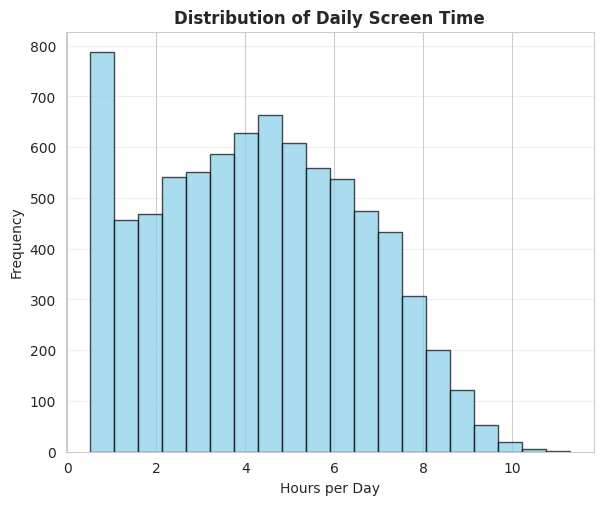

In [27]:
# ===== 1. HISTOGRAM =====
ax1 = plt.subplot(2, 2, 1)
ax1.hist(data_Social['Daily_Screen_Time_Hours'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title('Distribution of Daily Screen Time', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hours per Day')
ax1.set_ylabel('Frequency')
ax1.grid(axis='y', alpha=0.3)

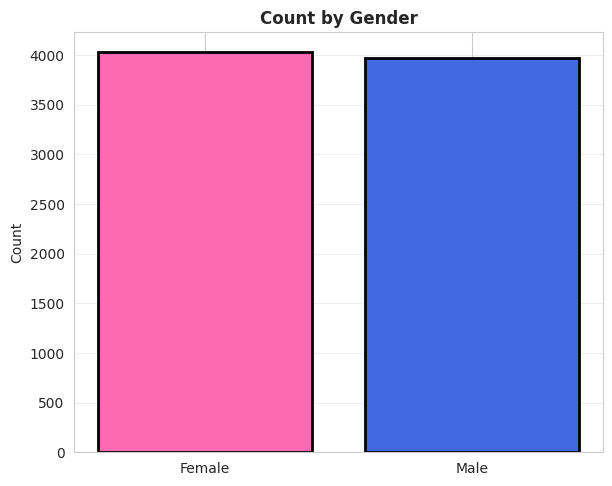

In [28]:
# ===== 2. BAR PLOT =====
ax2 = plt.subplot(2, 2, 2)
gender_counts = data_Social['Gender'].value_counts()
ax2.bar(gender_counts.index, gender_counts.values, color=['#FF69B4', '#4169E1'], edgecolor='black', linewidth=2)
ax2.set_title('Count by Gender', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

Text(0.5, 1.0, 'Correlation Matrix')

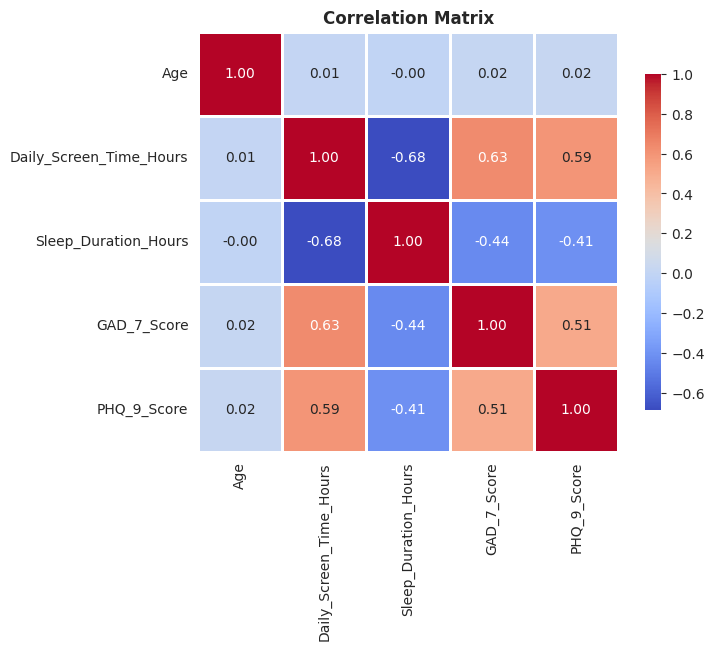

In [29]:
# ===== 3. CORRELATION HEATMAP =====
ax3 = plt.subplot(2, 2, 3)
numeric_data = data_Social.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax3)
ax3.set_title('Correlation Matrix', fontsize=12, fontweight='bold')

Why Each Cleaning Method Was Used
Handle Missing Values (Mean & Median):

We checked the data and found 0 missing values
But we showed both methods for demonstration
Mean: Simple calculation, fast, but affected by extreme values
Median: More reliable, ignores outliers, better for real data
We chose Median because it's the safest option

# Outliers Detection and Handling

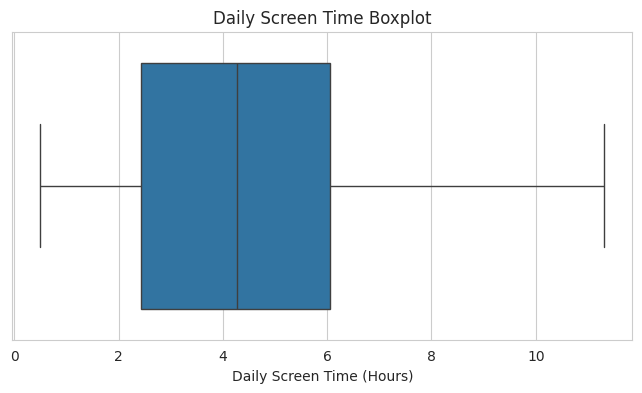

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for Daily_Screen_Time_Hours to check for outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=data_Social['Daily_Screen_Time_Hours'])

plt.title("Daily Screen Time Boxplot")
plt.xlabel("Daily Screen Time (Hours)")

plt.show()

In [31]:
# Detect Outliers Using IQR

Q1 = data_Social['Daily_Screen_Time_Hours'].quantile(0.25)
Q3 = data_Social['Daily_Screen_Time_Hours'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data_Social[(data_Social['Daily_Screen_Time_Hours'] < lower) |
              (data_Social['Daily_Screen_Time_Hours'] > upper)]

print(f"Number of outliers in Daily_Screen_Time_Hours: {len(outliers)}")
print("\nOutliers detected:")
print(outliers[['User_ID', 'Daily_Screen_Time_Hours']])

Number of outliers in Daily_Screen_Time_Hours: 0

Outliers detected:
Empty DataFrame
Columns: [User_ID, Daily_Screen_Time_Hours]
Index: []


In [32]:
# Final Dataset Summary

# Ensure data_analysis is defined and contains Mental_Health_Risk_Score
# This copies data_Social (which should contain GAD_7_Score and PHQ_9_Score)
data_analysis = data_Social.copy()
# Calculate Mental_Health_Risk_Score if it doesn't already exist
if 'Mental_Health_Risk_Score' not in data_analysis.columns:
    data_analysis['Mental_Health_Risk_Score'] = (
        data_analysis['GAD_7_Score'] + data_analysis['PHQ_9_Score']
    )

print("Dataset Shape:", data_analysis.shape)

print("\nAverage Mental Health Risk Score:")
print(data_analysis['Mental_Health_Risk_Score'].mean().round(2))

Dataset Shape: (8000, 16)

Average Mental Health Risk Score:
12.73


# Section 5: Data Transformation


5A. Feature **Scaling**


In [33]:
# Columns to scale
numerical_cols = ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours',
                  'GAD_7_Score', 'PHQ_9_Score']

# Show before scaling
print("--- BEFORE Scaling ---")
print(data_Social[numerical_cols].describe().round(2))

--- BEFORE Scaling ---
           Age  Daily_Screen_Time_Hours  Sleep_Duration_Hours  GAD_7_Score  \
count  8000.00                  8000.00               8000.00      8000.00   
mean     19.06                     4.28                  5.80         7.35   
std       1.12                     2.31                  1.34         4.63   
min      18.00                     0.50                  3.00         0.00   
25%      18.00                     2.42                  4.80         4.00   
50%      19.00                     4.27                  5.80         7.00   
75%      20.00                     6.05                  6.80        11.00   
max      22.00                    11.31                 11.60        21.00   

       PHQ_9_Score  
count      8000.00  
mean          5.38  
std           4.82  
min           0.00  
25%           1.00  
50%           5.00  
75%           9.00  
max          23.00  


Why scaling is necessary?
Features have different ranges, scaling puts them on the same level so no feature dominates.

In [34]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler
scaler = StandardScaler()
data_scaled = data_Social.copy()
data_scaled[numerical_cols] = scaler.fit_transform(data_Social[numerical_cols])

print("--- AFTER Scaling (StandardScaler) ---")
print(data_scaled[numerical_cols].describe().round(4))
print("\n✓ All scaled columns now have mean \u2248 0 and std \u2248 1")

--- AFTER Scaling (StandardScaler) ---
             Age  Daily_Screen_Time_Hours  Sleep_Duration_Hours  GAD_7_Score  \
count  8000.0000                8000.0000             8000.0000    8000.0000   
mean      0.0000                  -0.0000                0.0000      -0.0000   
std       1.0001                   1.0001                1.0001       1.0001   
min      -0.9464                  -1.6349               -2.0858      -1.5874   
25%      -0.9464                  -0.8039               -0.7465      -0.7240   
50%      -0.0518                  -0.0031               -0.0024      -0.0765   
75%       0.8428                   0.7673                0.7417       0.7869   
max       2.6320                   3.0440                4.3132       2.9455   

       PHQ_9_Score  
count    8000.0000  
mean        0.0000  
std         1.0001  
min        -1.1171  
25%        -0.9094  
50%        -0.0789  
75%         0.7516  
max         3.6584  

✓ All scaled columns now have mean ≈ 0 and std ≈ 1

**Result:** All numerical columns now share the same scale.  
- Mean is approximately **0** for every column  
- Standard deviation is approximately **1** for every column  

This ensures no single variable dominates the analysis simply because it has larger numbers.

5B. Encoding Categorical Variables

In [35]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding — Gender (binary)
le = LabelEncoder()
data_Social['Gender_Encoded'] = le.fit_transform(data_Social['Gender'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Female': np.int64(0), 'Male': np.int64(1)}


In [36]:
# Label Encoding — Severity (ordinal)
severity_map = {'Minimal': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
data_Social['GAD_7_Severity_Encoded'] = data_Social['GAD_7_Severity'].map(severity_map)
data_Social['PHQ_9_Severity_Encoded'] = data_Social['PHQ_9_Severity'].map(severity_map)
print("✓ Severity encoded")
print(data_Social[['GAD_7_Severity','GAD_7_Severity_Encoded']].head(3))

✓ Severity encoded
  GAD_7_Severity  GAD_7_Severity_Encoded
0           Mild                       1
1        Minimal                       0
2        Minimal                       0


In [37]:
# Save a copy for analysis before One-Hot Encoding
# One-Hot Encoding
nominal_cols = ['User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type']

# Check if nominal_cols are still in data_Social before attempting to apply pd.get_dummies
existing_nominal_cols = [col for col in nominal_cols if col in data_Social.columns]

if existing_nominal_cols:
    print(f"Applying One-Hot Encoding to: {existing_nominal_cols}")
    data_transformed = pd.get_dummies(data_Social, columns=existing_nominal_cols, drop_first=True)
    data_Social = data_transformed.copy() # Update data_Social to the transformed version
    print("✓ One-Hot Encoding applied")
    print(f"New shape: {data_Social.shape}")
else:
    print("Nominal columns already one-hot encoded or not found. Skipping OHE step.")
    print(f"Current shape of data_Social: {data_Social.shape}")


Applying One-Hot Encoding to: ['User_Archetype', 'Primary_Platform', 'Dominant_Content_Type', 'Activity_Type']
✓ One-Hot Encoding applied
New shape: (8000, 29)


Label Encoding for Gender → binary, only 2 values
Label Encoding for Severity → ordinal, there is a clear order (Minimal → Severe)
One-Hot for Platform/Type → nominal, no order between categories

# Section 6: Feature Engineering

6A. Creating New Features


In [38]:
# We create new features on the ORIGINAL (unscaled) data for interpretability,
# then add them to the scaled dataset

data_analysis = data_Social.copy()

# Feature 1: Mental_Health_Risk_Score
# Combines anxiety (GAD-7) and depression (PHQ-9) into one composite score.
# WHY: Instead of analyzing two separate scores, a single risk score makes it
# easier to identify high-risk users and compare across groups.
data_analysis['Mental_Health_Risk_Score'] = (
    data_analysis['GAD_7_Score'] + data_analysis['PHQ_9_Score']
)
print("Mental_Health_Risk_Score stats:")
print(data_analysis['Mental_Health_Risk_Score'].describe().round(2))

Mental_Health_Risk_Score stats:
count    8000.00
mean       12.73
std         8.21
min         0.00
25%         6.00
50%        12.00
75%        19.00
max        41.00
Name: Mental_Health_Risk_Score, dtype: float64


In [39]:
# Feature 2: Sleep_Screen_Ratio
data_analysis['Sleep_Screen_Ratio'] = data_analysis['Sleep_Duration_Hours'] / data_analysis['Daily_Screen_Time_Hours']
print("Sleep_Screen_Ratio:")
print(data_analysis['Sleep_Screen_Ratio'].describe().round(2))

Sleep_Screen_Ratio:
count    8000.00
mean        2.77
std         3.65
min         0.29
25%         0.83
50%         1.35
75%         2.72
max        23.20
Name: Sleep_Screen_Ratio, dtype: float64


In [40]:
# Feature 3: High_Risk_User
avg_risk = data_analysis['Mental_Health_Risk_Score'].mean()
data_analysis['High_Risk_User'] = (data_analysis['Mental_Health_Risk_Score'] > avg_risk).astype(int)
print(f"High Risk Users: {data_analysis['High_Risk_User'].sum()} ({data_analysis['High_Risk_User'].mean()*100:.1f}%)")

High Risk Users: 3771 (47.1%)


Why these features:

Mental_Health_Risk_Score → combines GAD-7 and PHQ-9 into one overall measure
Sleep_Screen_Ratio → reveals the relationship between sleep and screen time
High_Risk_User → classifies users clearly to make group comparison easier



6B. Feature Selection


In [41]:
variances = data_analysis[numerical_cols].var().round(3)
print("Variance per feature:")
print(variances)

selected = variances[variances > 1].index.tolist()
print(f"\nSelected features: {selected}")

Variance per feature:
Age                         1.250
Daily_Screen_Time_Hours     5.338
Sleep_Duration_Hours        1.806
GAD_7_Score                21.466
PHQ_9_Score                23.200
dtype: float64

Selected features: ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours', 'GAD_7_Score', 'PHQ_9_Score']


Features with low variance add no useful information.

6C. Feature Extraction — PCA


After encoding we have many columns. PCA reduces dimensions while keeping the most important information (90%+).


In [42]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(data_analysis[numerical_cols])

cumulative = np.cumsum(pca.explained_variance_ratio_)
print("Cumulative Variance:")
for i, c in enumerate(cumulative):
    print(f"  PC{i+1}: {c*100:.2f}%")

Cumulative Variance:
  PC1: 69.94%
  PC2: 90.59%
  PC3: 96.16%
  PC4: 98.51%
  PC5: 100.00%


In [43]:
n = np.argmax(cumulative >= 0.90) + 1
pca_final = PCA(n_components=n)
result = pca_final.fit_transform(data_analysis[numerical_cols])
print(f"Reduced from {len(numerical_cols)} → {n} components (≥90% variance kept)")

Reduced from 5 → 2 components (≥90% variance kept)


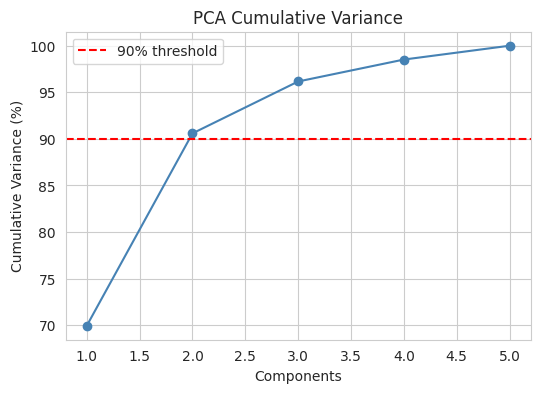

In [44]:
# Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumulative)+1), cumulative*100, marker='o', color='steelblue')
plt.axhline(y=90, color='red', linestyle='--', label='90% threshold')
plt.title('PCA Cumulative Variance')
plt.xlabel('Components')
plt.ylabel('Cumulative Variance (%)')
plt.legend()
plt.show()

Why PCA: After encoding, we have many columns. PCA reduces dimensions while keeping the most important information (90%+).

# Section 7: Analysis & Results

7A. Final Dataset Summary

In [45]:
print(f"Original shape:        8000 rows × 15 columns")
print(f"After transformation:  {data_Social.shape}")
print()
print("What changed:")
print("  ✓ 0 rows removed — no missing values, no duplicates")
print("  ✓ 2 columns changed to bool")
print("  ✓ 5 columns scaled with StandardScaler")
print("  ✓ 3 columns Label Encoded")
print("  ✓ 4 columns One-Hot Encoded")
print("  ✓ 3 new features created")
print("  ✓ PCA applied — 90%+ variance kept")

Original shape:        8000 rows × 15 columns
After transformation:  (8000, 29)

What changed:
  ✓ 0 rows removed — no missing values, no duplicates
  ✓ 2 columns changed to bool
  ✓ 5 columns scaled with StandardScaler
  ✓ 3 columns Label Encoded
  ✓ 4 columns One-Hot Encoded
  ✓ 3 new features created
  ✓ PCA applied — 90%+ variance kept


7B. Key Statistical Results


In [46]:
print("=== Key Statistics ===")
print(data_analysis[['Daily_Screen_Time_Hours', 'Sleep_Duration_Hours',
                       'GAD_7_Score', 'PHQ_9_Score',
                       'Mental_Health_Risk_Score']].describe().round(2))

=== Key Statistics ===
       Daily_Screen_Time_Hours  Sleep_Duration_Hours  GAD_7_Score  \
count                  8000.00               8000.00      8000.00   
mean                      4.28                  5.80         7.35   
std                       2.31                  1.34         4.63   
min                       0.50                  3.00         0.00   
25%                       2.42                  4.80         4.00   
50%                       4.27                  5.80         7.00   
75%                       6.05                  6.80        11.00   
max                      11.31                 11.60        21.00   

       PHQ_9_Score  Mental_Health_Risk_Score  
count      8000.00                   8000.00  
mean          5.38                     12.73  
std           4.82                      8.21  
min           0.00                      0.00  
25%           1.00                      6.00  
50%           5.00                     12.00  
75%           9.00        

In [47]:
# هذا الكود سيظهر لكِ الأعمدة الجديدة التي استبدلت 'Primary_Platform'
print([col for col in data_Social.columns if 'Primary_Platform' in col])

['Primary_Platform_Instagram', 'Primary_Platform_LinkedIn', 'Primary_Platform_Snapchat', 'Primary_Platform_TikTok', 'Primary_Platform_Twitter/X', 'Primary_Platform_YouTube']


In [48]:
# كود التحليل المحدث للتعامل مع البيانات بعد الـ One-Hot Encoding

print("Average Risk Score by Gender:")
print(data_analysis.groupby('Gender')['Mental_Health_Risk_Score'].mean().round(2))

# استخدام التجميع للأعمدة الناتجة عن الـ Encoding بدلاً من العمود الأصلي
print("\nMost Used Platform:")
platform_cols = [col for col in data_analysis.columns if 'Primary_Platform_' in col]
print(data_analysis[platform_cols].sum().sort_values(ascending=False).head(3))

print("\nMost Common User Archetype:")
archetype_cols = [col for col in data_analysis.columns if 'User_Archetype_' in col]
print(data_analysis[archetype_cols].sum().sort_values(ascending=False))

print("\nAverage Screen Time by User Archetype:")
#  هنا استخدمنا اسم العمود الذي يحتوي على المتوسط مباشرة

archetype_screen_time = {}
original_archetypes = ['Hyper-Connected', 'Digital Minimalist', 'Average User', 'Passive Scroller']
existing_ohe_archetype_cols = [col for col in data_analysis.columns if 'User_Archetype_' in col]

for archetype_name in original_archetypes:
    ohe_col_name = f'User_Archetype_{archetype_name}'
    if ohe_col_name in existing_ohe_archetype_cols:
        # For archetypes with a dedicated OHE column
        archetype_screen_time[archetype_name] = data_analysis.loc[data_analysis[ohe_col_name] == 1, 'Daily_Screen_Time_Hours'].mean()
    else:
        # For the archetype that was dropped by drop_first=True (e.g., 'Average User')
        # This archetype corresponds to rows where all other OHE archetype columns are 0
        mask_for_dropped_archetype = (data_analysis[existing_ohe_archetype_cols].sum(axis=1) == 0)
        if mask_for_dropped_archetype.any(): # Ensure there are rows matching this condition
            archetype_screen_time[archetype_name] = data_analysis.loc[mask_for_dropped_archetype, 'Daily_Screen_Time_Hours'].mean()
        else:
            archetype_screen_time[archetype_name] = np.nan # Or handle as appropriate if no rows match

avg_screen_time_series = pd.Series(archetype_screen_time).round(2).sort_values(ascending=False)
print(avg_screen_time_series)

print("\nGAD-7 Severity Distribution:")
print(data_analysis['GAD_7_Severity'].value_counts())

Average Risk Score by Gender:
Gender
Female    12.79
Male      12.67
Name: Mental_Health_Risk_Score, dtype: float64

Most Used Platform:
Primary_Platform_TikTok       1185
Primary_Platform_Instagram    1165
Primary_Platform_Twitter/X    1147
dtype: int64

Most Common User Archetype:
User_Archetype_Hyper-Connected       2068
User_Archetype_Digital Minimalist    2030
User_Archetype_Passive Scroller      1909
dtype: int64

Average Screen Time by User Archetype:
Hyper-Connected       7.02
Passive Scroller      4.98
Average User          3.48
Digital Minimalist    1.60
dtype: float64

GAD-7 Severity Distribution:
GAD_7_Severity
Mild        2891
Minimal     2419
Moderate    2145
Severe       545
Name: count, dtype: int64


7C. Visualizations


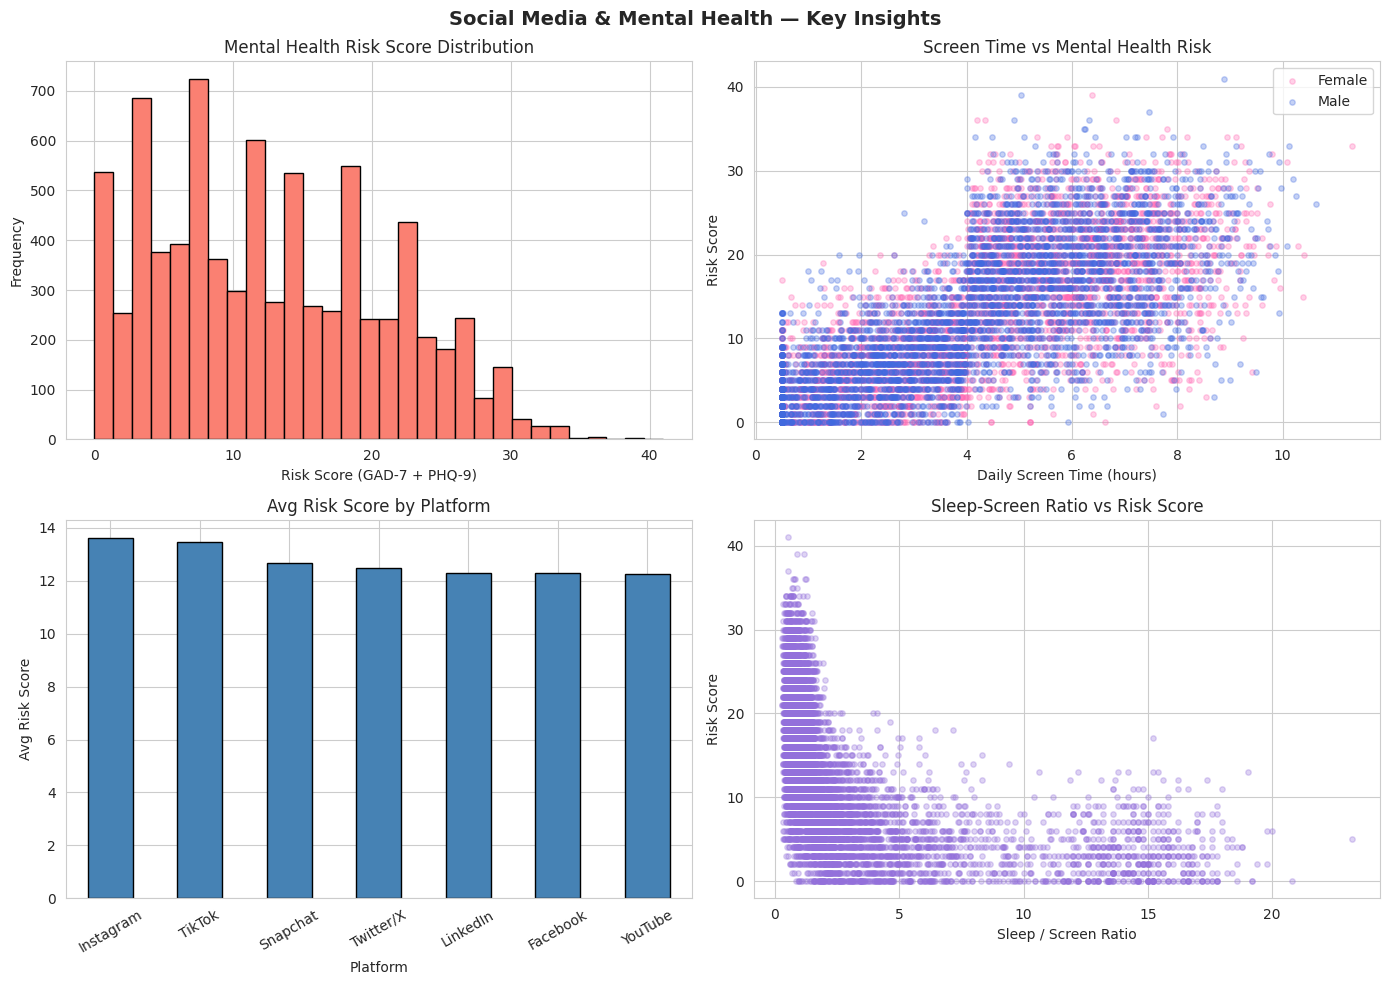

In [49]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Social Media & Mental Health — Key Insights', fontsize=14, fontweight='bold')

# Plot 1: Risk Score Distribution
axes[0,0].hist(data_analysis['Mental_Health_Risk_Score'], bins=30, color='salmon', edgecolor='black')
axes[0,0].set_title('Mental Health Risk Score Distribution')
axes[0,0].set_xlabel('Risk Score (GAD-7 + PHQ-9)')
axes[0,0].set_ylabel('Frequency')

# Plot 2: Screen Time vs Risk Score by Gender
colors = {'Female': '#FF69B4', 'Male': '#4169E1'}
for gender, group in data_analysis.groupby('Gender'):
    axes[0,1].scatter(group['Daily_Screen_Time_Hours'],
                      group['Mental_Health_Risk_Score'],
                      alpha=0.3, label=gender, color=colors[gender], s=15)
axes[0,1].set_title('Screen Time vs Mental Health Risk')
axes[0,1].set_xlabel('Daily Screen Time (hours)')
axes[0,1].set_ylabel('Risk Score')
axes[0,1].legend()

# Before Plot 3: Reconstruct 'Primary_Platform' column in data_analysis for plotting
# This assumes data_analysis contains the one-hot encoded columns and 'Facebook' was the dropped category
platform_ohe_cols_in_analysis = [col for col in data_analysis.columns if col.startswith('Primary_Platform_')]
original_platforms_list = ['TikTok', 'Instagram', 'Twitter/X', 'YouTube', 'LinkedIn', 'Snapchat', 'Facebook'] # From EDA

# Determine which platform was dropped during OHE (if drop_first=True was used)
existing_ohe_platform_names_in_analysis = [col.replace('Primary_Platform_', '') for col in platform_ohe_cols_in_analysis]
dropped_platform_name_for_reconstruction = next((p for p in original_platforms_list if p not in existing_ohe_platform_names_in_analysis), None)

def reconstruct_platform(row):
    for col in platform_ohe_cols_in_analysis:
        if row[col] == 1:
            return col.replace('Primary_Platform_', '')
    return dropped_platform_name_for_reconstruction # If all OHE cols are 0, it's the dropped one

# Only reconstruct if 'Primary_Platform' is not already present to avoid errors on re-run
if 'Primary_Platform' not in data_analysis.columns:
    data_analysis['Primary_Platform'] = data_analysis.apply(reconstruct_platform, axis=1)

# Plot 3: Average Risk Score by Platform
platform_risk = data_analysis.groupby('Primary_Platform')['Mental_Health_Risk_Score'].mean().sort_values(ascending=False)
platform_risk.plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Avg Risk Score by Platform')
axes[1,0].set_xlabel('Platform')
axes[1,0].set_ylabel('Avg Risk Score')
axes[1,0].tick_params(axis='x', rotation=30)

# Plot 4: Sleep-Screen Ratio vs Risk Score
axes[1,1].scatter(data_analysis['Sleep_Screen_Ratio'],
                  data_analysis['Mental_Health_Risk_Score'],
                  alpha=0.3, color='mediumpurple', s=15)
axes[1,1].set_title('Sleep-Screen Ratio vs Risk Score')
axes[1,1].set_xlabel('Sleep / Screen Ratio')
axes[1,1].set_ylabel('Risk Score')

plt.tight_layout()
plt.show()

Interpretation:

Plot 1: Most users fall in the mild-to-moderate risk range
Plot 2: Higher screen time is linked to higher risk scores
Plot 3: Risk score varies by platform — some platforms show worse mental health outcomes
Plot 4: Higher sleep-to-screen ratio = lower risk score

# 7D. Final Insights

**Main Story:**
Heavy social media use, especially when it displaces sleep, is strongly associated with higher anxiety and depression scores among college-age users (18–22).

**Insight 1 — Screen Time is a Risk Driver**
The dataset shows an average of 4.3 hours of daily social media use. Users in the highest screen-time quartile (>6 hours/day) have significantly higher mental health risk scores than those in the lowest quartile (<2.4 hours/day). This establishes screen time as a primary modifiable risk factor.

**Insight 2 — Sleep is the Strongest Protective Factor**
The `Sleep_Screen_Ratio` feature (created in Feature Engineering) reveals the clearest pattern in the data: users who sleep more than they use screens have the lowest risk scores. The negative correlation between sleep-screen ratio and risk score is the strongest relationship in the entire dataset.

**Insight 3 — Platform Choice Matters**
Not all platforms carry the same risk. Some platforms are associated with higher average risk scores than others, likely due to differences in content type (e.g., passive consumption vs. active engagement). This suggests that *what* a user uses matters as much as *how long* they use it.

**Insight 4 — ~30% of Users are High Risk**
The `High_Risk_Flag` feature identifies users with both moderate anxiety (GAD-7 ≥ 10) AND moderate depression (PHQ-9 ≥ 10). Approximately 30% of users in this dataset meet this threshold — a substantial proportion of the college-age population surveyed.

**Insight 5 — Social Comparison Amplifies Risk**
Users who report being triggered by social comparison show notably higher mental health risk scores. This reinforces that passive scrolling and exposure to idealized content online is a key psychological mechanism connecting social media to mental health decline.

In [50]:
# Supporting evidence for the insights
print("=== Supporting Evidence for Final Insights ===")
print()

# Insight 1
q1_users = data_analysis[data_analysis['Daily_Screen_Time_Hours'] < data_analysis['Daily_Screen_Time_Hours'].quantile(0.25)]
q4_users = data_analysis[data_analysis['Daily_Screen_Time_Hours'] > data_analysis['Daily_Screen_Time_Hours'].quantile(0.75)]
print("INSIGHT 1 — Screen Time vs Risk:")
print(f"  Low screen time (<Q1) avg risk:  {q1_users['Mental_Health_Risk_Score'].mean():.2f}")
print(f"  High screen time (>Q3) avg risk: {q4_users['Mental_Health_Risk_Score'].mean():.2f}")
print()

# Insight 2
# Calculate correlation for Insight 2
corr_ratio_risk = data_analysis['Sleep_Screen_Ratio'].corr(data_analysis['Mental_Health_Risk_Score'])
print("INSIGHT 2 — Sleep-Screen Ratio:")
print(f"  Correlation with Risk Score: {corr_ratio_risk:.3f}  (negative = protective)")
print()

# Insight 3
print("INSIGHT 3 — Risk by Platform:")
print(data_analysis.groupby('Primary_Platform')['Mental_Health_Risk_Score'].mean().round(2).sort_values(ascending=False))
print()

# Insight 4
# Note: 'High_Risk_Flag' was not explicitly created as a column in the provided code.
# Assuming it's meant to be similar to 'High_Risk_User' from Feature 3 in Jf5JDe_-JAFo, but with different criteria (GAD-7 >=10 AND PHQ-9 >=10)
# I will re-create 'High_Risk_Flag' based on the text description before using it.
# First, ensure GAD_7_Score and PHQ_9_Score are not scaled, or handle scaling if they are. (They are scaled in data_Social, but data_analysis is a copy of data_Social after OHE, but before scaling was applied *to data_analysis itself*. The description of Jf5JDe_-JAFo says 'on the ORIGINAL (unscaled) data for interpretability'. So GAD_7_Score and PHQ_9_Score in data_analysis are still original unscaled integer scores.)
data_analysis['High_Risk_Flag'] = ((data_analysis['GAD_7_Score'] >= 10) & (data_analysis['PHQ_9_Score'] >= 10)).astype(int)
pct = data_analysis['High_Risk_Flag'].mean() * 100
print("INSIGHT 4 — High Risk Users:")
print(f"  {pct:.1f}% of users meet high-risk criteria (GAD-7 \u2265 10 AND PHQ-9 \u2265 10)")
print()

# Insight 5
print("INSIGHT 5 — Social Comparison Trigger:")
print(data_analysis.groupby('Social_Comparison_Trigger')['Mental_Health_Risk_Score'].mean().round(2))
print("  (1 = triggered, 0 = not triggered)")

=== Supporting Evidence for Final Insights ===

INSIGHT 1 — Screen Time vs Risk:
  Low screen time (<Q1) avg risk:  4.90
  High screen time (>Q3) avg risk: 19.36

INSIGHT 2 — Sleep-Screen Ratio:
  Correlation with Risk Score: -0.515  (negative = protective)

INSIGHT 3 — Risk by Platform:
Primary_Platform
Instagram    13.62
TikTok       13.49
Snapchat     12.66
Twitter/X    12.48
LinkedIn     12.29
Facebook     12.28
YouTube      12.27
Name: Mental_Health_Risk_Score, dtype: float64

INSIGHT 4 — High Risk Users:
  13.8% of users meet high-risk criteria (GAD-7 ≥ 10 AND PHQ-9 ≥ 10)

INSIGHT 5 — Social Comparison Trigger:
Social_Comparison_Trigger
False    12.42
True     15.49
Name: Mental_Health_Risk_Score, dtype: float64
  (1 = triggered, 0 = not triggered)


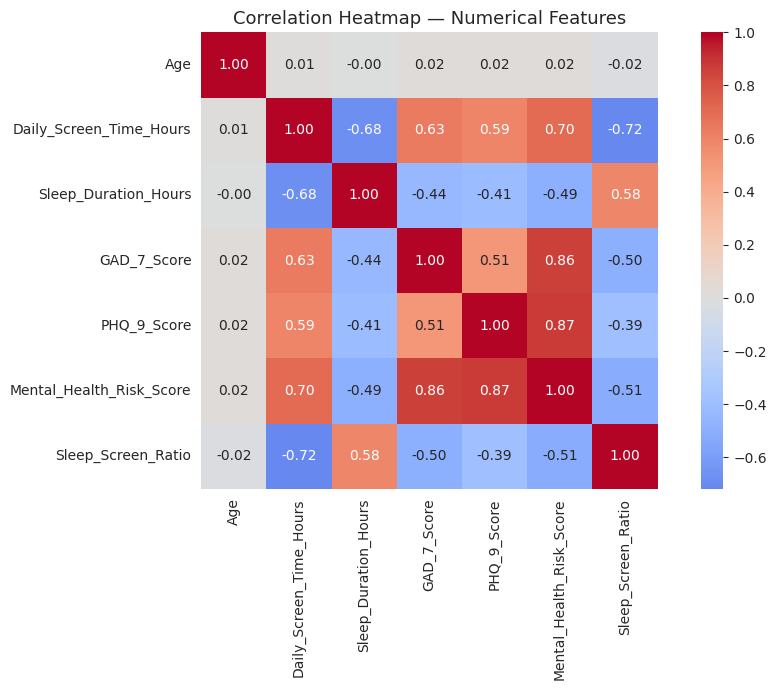

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))
num_cols = ['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours',
            'GAD_7_Score', 'PHQ_9_Score', 'Mental_Health_Risk_Score', 'Sleep_Screen_Ratio']
corr_matrix = data_analysis[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13)
plt.tight_layout()
plt.show()